<a href="https://colab.research.google.com/github/Ravi-ranjan1801/DIP-Lab/blob/main/dip_lab_10_Advanced_Morphology.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Lab 10**

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

(np.float64(-0.5), np.float64(4031.5), np.float64(2687.5), np.float64(-0.5))

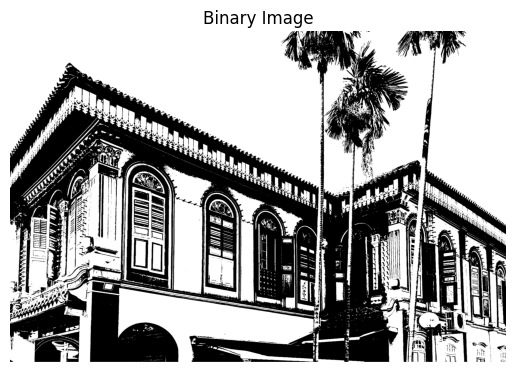

In [2]:
img = cv2.imread('img.webp',0)

_, binary = cv2.threshold(img,127,255,cv2.THRESH_BINARY)

plt.imshow(binary, cmap='gray')
plt.title("Binary Image")
plt.axis('off')

### PART 1 — Boundary Extraction & Region Filling

(np.float64(-0.5), np.float64(4031.5), np.float64(2687.5), np.float64(-0.5))

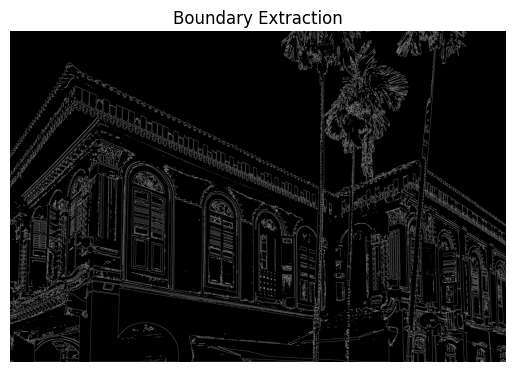

In [3]:
kernel = np.ones((3,3),np.uint8)

erosion = cv2.erode(binary, kernel)

boundary = binary - erosion

plt.imshow(boundary, cmap='gray')
plt.title("Boundary Extraction")
plt.axis('off')

(np.float64(-0.5), np.float64(4031.5), np.float64(2687.5), np.float64(-0.5))

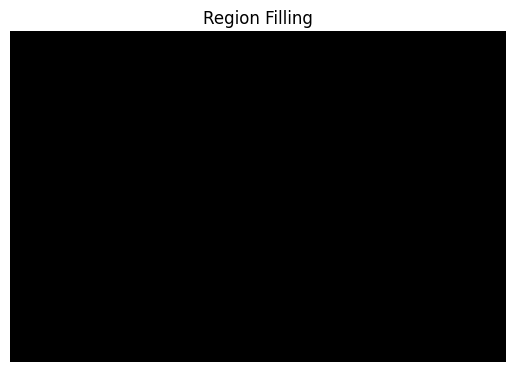

In [4]:
filled = binary.copy()

h, w = binary.shape
mask = np.zeros((h+2, w+2), np.uint8)

# seed point (background area)
cv2.floodFill(filled, mask, (0,0), 255)

filled = cv2.bitwise_not(filled)
result = binary | filled

plt.imshow(result, cmap='gray')
plt.title("Region Filling")
plt.axis('off')

### PART 2 — Connected Components

(np.float64(-0.5), np.float64(4031.5), np.float64(2687.5), np.float64(-0.5))

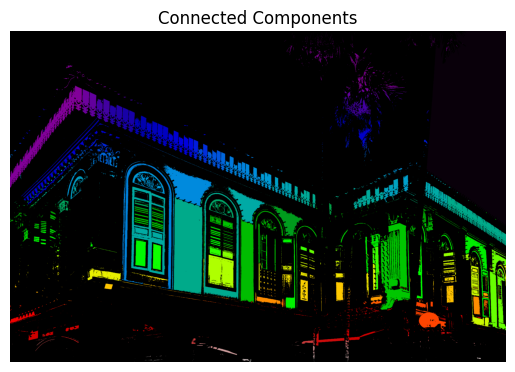

In [5]:
num, labels = cv2.connectedComponents(binary)

plt.imshow(labels, cmap='nipy_spectral')
plt.title("Connected Components")
plt.axis('off')

Hit-or-Miss Transform

(np.float64(-0.5), np.float64(4031.5), np.float64(2687.5), np.float64(-0.5))

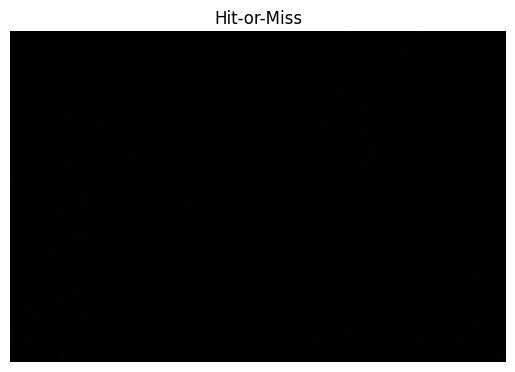

In [6]:
kernel = np.array([[0,1,0],
                   [1,-1,1],
                   [0,1,0]])

hitmiss = cv2.morphologyEx(binary, cv2.MORPH_HITMISS, kernel)

plt.imshow(hitmiss, cmap='gray')
plt.title("Hit-or-Miss")
plt.axis('off')

Convex Hull

(np.float64(-0.5), np.float64(4031.5), np.float64(2687.5), np.float64(-0.5))

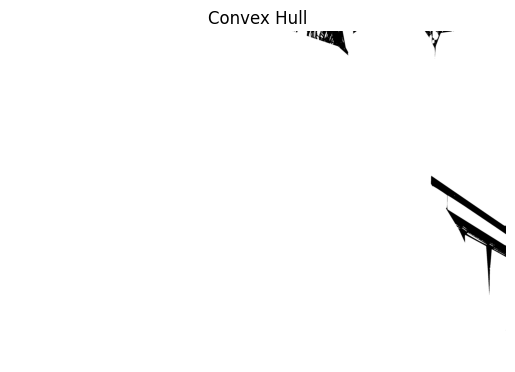

In [7]:
contours,_ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

hull_img = np.zeros_like(binary)

for cnt in contours:
    hull = cv2.convexHull(cnt)
    cv2.drawContours(hull_img,[hull],0,255,-1)

plt.imshow(hull_img, cmap='gray')
plt.title("Convex Hull")
plt.axis('off')

Thinning

(np.float64(-0.5), np.float64(4031.5), np.float64(2687.5), np.float64(-0.5))

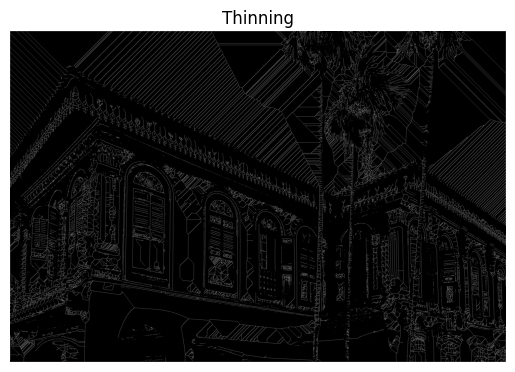

In [8]:
thin = cv2.ximgproc.thinning(binary)

plt.imshow(thin, cmap='gray')
plt.title("Thinning")
plt.axis('off')

Thickening

(np.float64(-0.5), np.float64(4031.5), np.float64(2687.5), np.float64(-0.5))

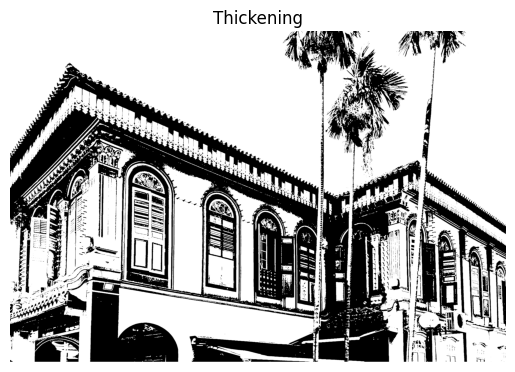

In [9]:
kernel = np.ones((3,3),np.uint8)

thick = cv2.dilate(binary, kernel)

plt.imshow(thick, cmap='gray')
plt.title("Thickening")
plt.axis('off')